<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-06-01 04:21:42--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite’

survey-results-publ 100%[===================>] 201.62M  36.8MB/s    in 5.2s    

2026-06-01 04:21:51 (38.4 MB/s) - ‘survey-results-public.sqlite’ saved [211415040/211415040]

--2026-06-01 04:21:52--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data

#### 2. Connect to the Database


**Install the needed libraries**


In [ ]:
!pip install pandas
!pip install pandas

In [2]:
!pip install matplotlib
!pip install matplotlib

In [12]:
import sqlite3

conn = sqlite3.connect("survey-results-public.sqlite")
cursor = conn.cursor()
cursor.execute("""
SELECT *
FROM main
LIMIT 10;
""")

rows = cursor.fetchall()
column_names = [description[0] for description in cursor.description]
print("Columns:")
print(column_names)

print("\nRows:")
for row in rows:
    print(row)
conn.close()

Columns:
['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith', 'ToolsTechAdmired', 'NEWCollabToolsHaveWorkedWith', 'NEWCollabToolsWantToWorkWith', 'NEWCollabToolsAdmired', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToW

## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [14]:
import sqlite3

conn = sqlite3.connect("survey-results-public.sqlite")
cursor = conn.cursor()

cursor.execute("SELECT COUNT(*) FROM main")

count = cursor.fetchone()[0]

print("Total rows:", count)

conn.close()


Total rows: 65437


#### Demo 2: List All Tables


In [17]:
import sqlite3

conn = sqlite3.connect("survey-results-public.sqlite")
cursor = conn.cursor()

cursor.execute("""
SELECT name AS Table_Name
FROM sqlite_master
WHERE type = 'table';
""")

tables = cursor.fetchall()

print("Tables in the database:")
for table in tables:
    print(table[0])
    
conn.close()

Tables in the database:
main


#### Demo 3: Group Data by Age


In [18]:
import sqlite3

conn = sqlite3.connect("survey-results-public.sqlite")
cursor = conn.cursor()

cursor.execute("""
SELECT Age, COUNT(*) AS Total_Respondents
FROM main
GROUP BY Age
ORDER BY Age;
""")

rows = cursor.fetchall()

print("Age | Total_Respondents")
print("-" * 30)
for row in rows:
    print(row)

# Close the connection
conn.close()

Age | Total_Respondents
------------------------------
('18-24 years old', 14098)
('25-34 years old', 23911)
('35-44 years old', 14942)
('45-54 years old', 6249)
('55-64 years old', 2575)
('65 years or older', 772)
('Prefer not to say', 322)
('Under 18 years old', 2568)


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 151.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 150.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 147.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 154.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 142.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Tables in Database:
  Table_Name
0       main

First 10 Rows:
   ResponseId                                         MainBranch  \
0           1                     I am a developer by profession   
1           2                     I am a developer by profession   
2           3                     I am a developer by profession   
3           4                              I am learning to code   
4           5                     I am a developer by profe

/tmp/ipykernel_301/1112240064.py:42: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(comp["CompTotal"], vert=False)


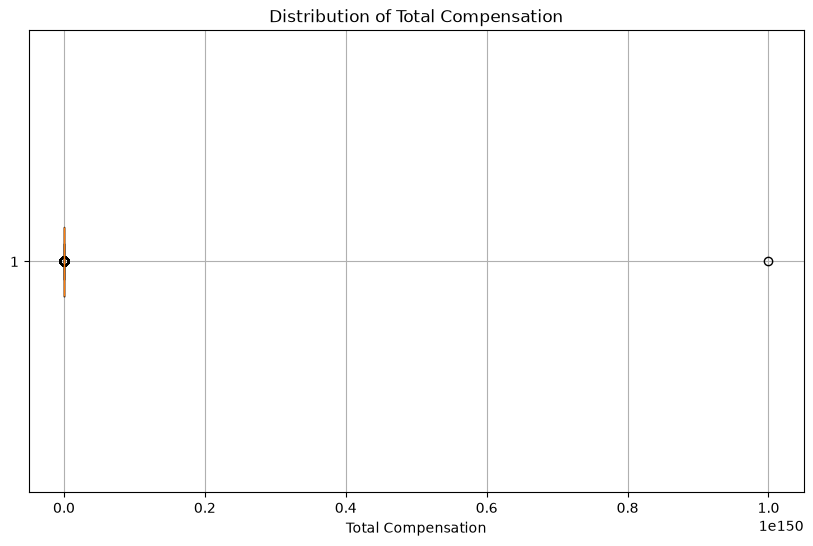

In [22]:
%pip install pandas matplotlib

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("survey-results-public.sqlite")

tables = pd.read_sql_query("""
SELECT name AS Table_Name
FROM sqlite_master
WHERE type='table';
""", conn)

print("Tables in Database:")
print(tables)

df = pd.read_sql_query("""
SELECT *
FROM main
LIMIT 10;
""", conn)

print("\nFirst 10 Rows:")
print(df)

count = pd.read_sql_query("""
SELECT COUNT(*) AS Total_Records
FROM main;
""", conn)

print("\nTotal Records:")
print(count)

comp = pd.read_sql_query("""
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL;
""", conn)

plt.figure(figsize=(10,6))
plt.boxplot(comp["CompTotal"], vert=False)
plt.title("Distribution of Total Compensation")
plt.xlabel("Total Compensation")
plt.grid(True)

plt.show()

conn.close()


**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 109.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 104.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


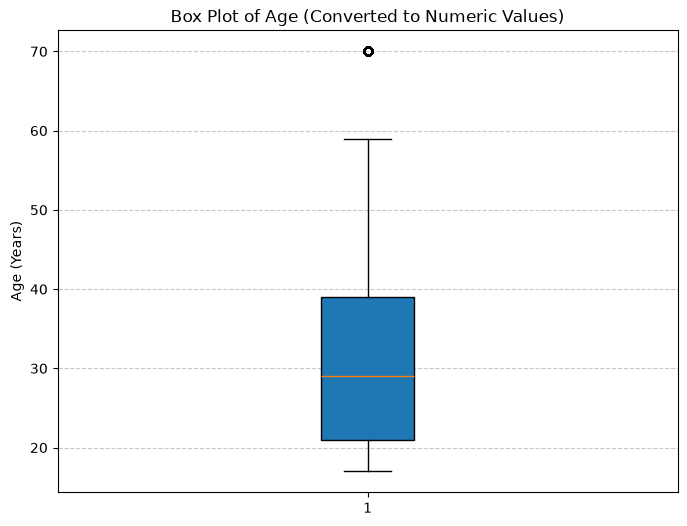

In [5]:

%pip install matplotlib

import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect("survey-results-public.sqlite")
cursor = conn.cursor()

cursor.execute("""
SELECT Age
FROM main
WHERE Age IS NOT NULL;
""")

ages = [row[0] for row in cursor.fetchall()]

conn.close()

age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

numeric_ages = [age_mapping[age] for age in ages if age in age_mapping]

plt.figure(figsize=(8, 6))
plt.boxplot(numeric_ages, patch_artist=True)

plt.title("Box Plot of Age (Converted to Numeric Values)")
plt.ylabel("Age (Years)")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


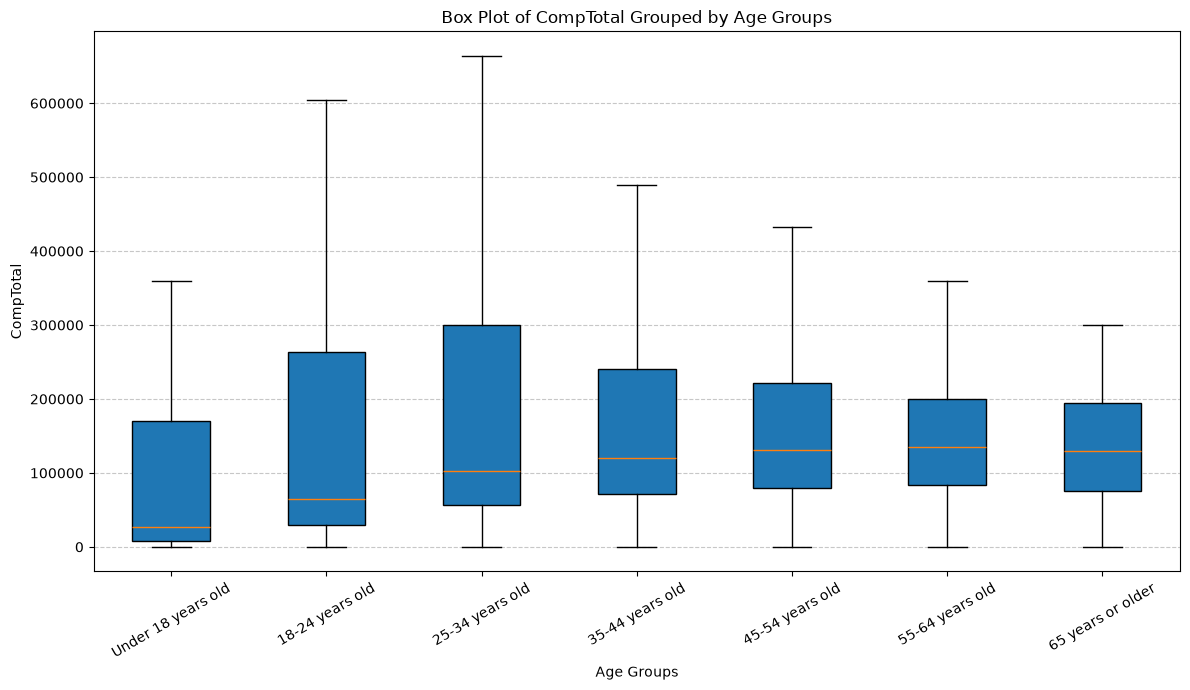

In [8]:
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect("survey-results-public.sqlite")
cursor = conn.cursor()

cursor.execute("""
SELECT Age, CompTotal
FROM main
WHERE Age IS NOT NULL
AND CompTotal IS NOT NULL;
""")

rows = cursor.fetchall()
conn.close()

age_groups = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

comp_by_age = {age: [] for age in age_groups}

for age, comp in rows:
    if age in comp_by_age:
        try:
            comp = float(comp)
            if comp > 0:
                comp_by_age[age].append(comp)
        except (ValueError, TypeError):
            continue

data = [comp_by_age[age] for age in age_groups]

plt.figure(figsize=(12, 7))

plt.boxplot(
    data,
    tick_labels=age_groups,
    patch_artist=True,
    showfliers=False
)

plt.title("Box Plot of CompTotal Grouped by Age Groups")
plt.xlabel("Age Groups")
plt.ylabel("CompTotal")
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


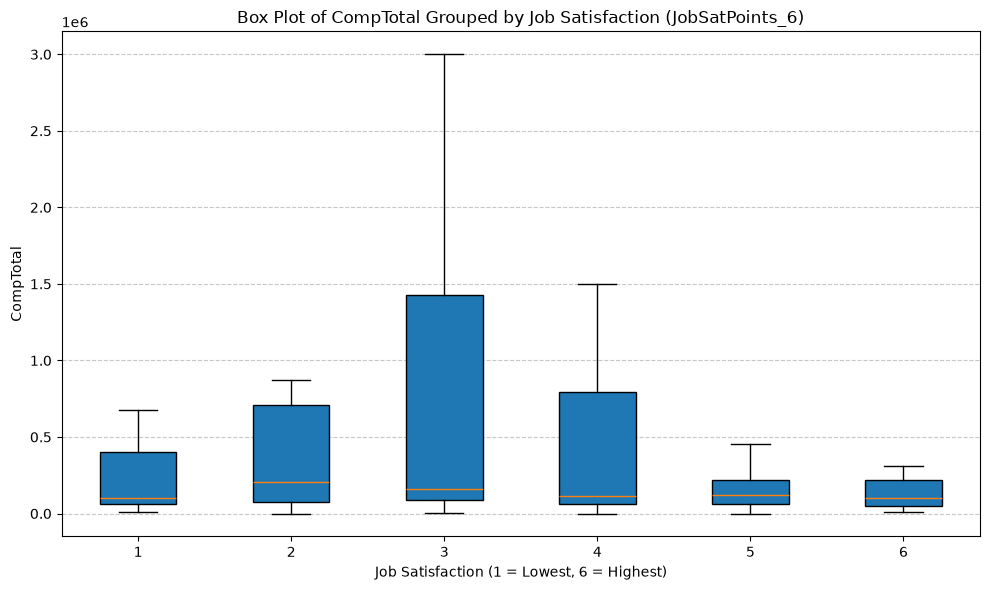

In [10]:
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect("survey-results-public.sqlite")
cursor = conn.cursor()

cursor.execute("""
SELECT JobSatPoints_6, CompTotal
FROM main
WHERE JobSatPoints_6 IS NOT NULL
AND CompTotal IS NOT NULL;
""")

rows = cursor.fetchall()

conn.close()

job_sat_levels = [1, 2, 3, 4, 5, 6]


comp_by_jobsat = {level: [] for level in job_sat_levels}

for jobsat, comp in rows:
    try:
        jobsat = int(jobsat)
        comp = float(comp)

        if jobsat in comp_by_jobsat and comp > 0:
            comp_by_jobsat[jobsat].append(comp)

    except (ValueError, TypeError):
        continue


data = [comp_by_jobsat[level] for level in job_sat_levels]

plt.figure(figsize=(10, 6))

plt.boxplot(
    data,
    tick_labels=[str(level) for level in job_sat_levels],
    patch_artist=True,
    showfliers=False
)

plt.title("Box Plot of CompTotal Grouped by Job Satisfaction (JobSatPoints_6)")
plt.xlabel("Job Satisfaction (1 = Lowest, 6 = Highest)")
plt.ylabel("CompTotal")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


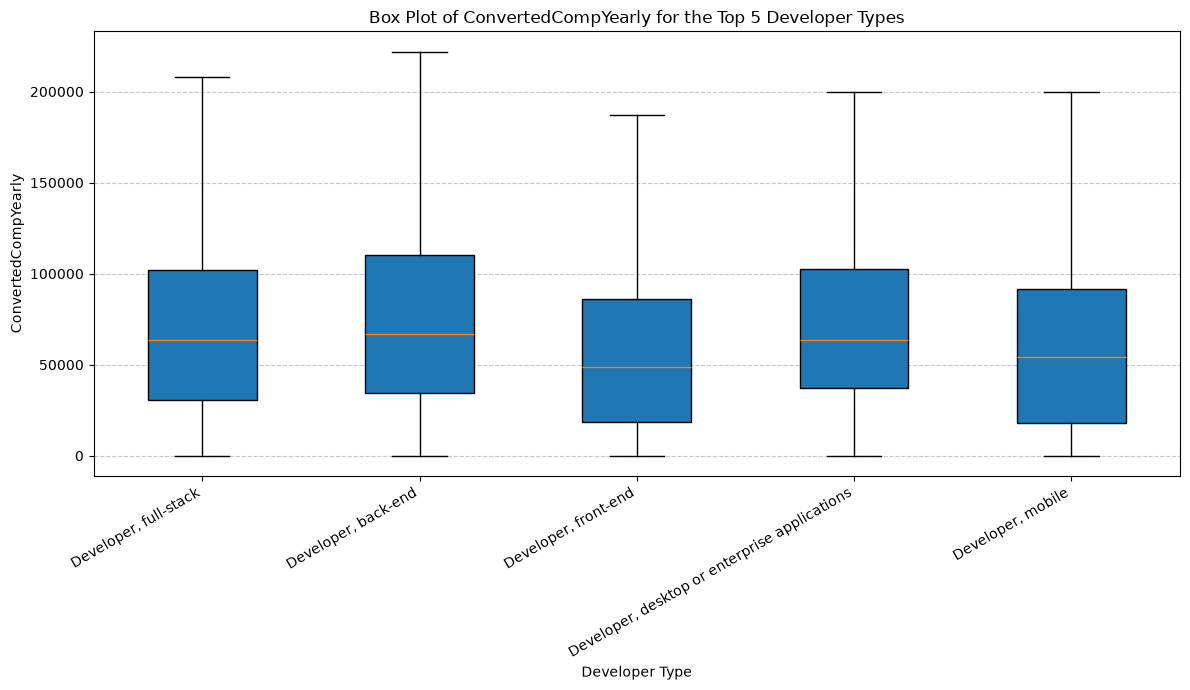

In [11]:
import sqlite3
import matplotlib.pyplot as plt
from collections import Counter

conn = sqlite3.connect("survey-results-public.sqlite")
cursor = conn.cursor()


cursor.execute("""
SELECT DevType, ConvertedCompYearly
FROM main
WHERE DevType IS NOT NULL
AND ConvertedCompYearly IS NOT NULL;
""")

rows = cursor.fetchall()

conn.close()

dev_counter = Counter()

for devtype, _ in rows:
    
    roles = [role.strip() for role in devtype.split(";")]
    dev_counter.update(roles)


top5 = [role for role, count in dev_counter.most_common(5)]

salary_data = {role: [] for role in top5}

for devtype, salary in rows:
    try:
        salary = float(salary)
        if salary <= 0:
            continue

        roles = [role.strip() for role in devtype.split(";")]

        for role in roles:
            if role in salary_data:
                salary_data[role].append(salary)

    except (ValueError, TypeError):
        continue


data = [salary_data[role] for role in top5]

plt.figure(figsize=(12, 7))

plt.boxplot(
    data,
    tick_labels=top5,     
    patch_artist=True,
    showfliers=False
)

plt.title("Box Plot of ConvertedCompYearly for the Top 5 Developer Types")
plt.xlabel("Developer Type")
plt.ylabel("ConvertedCompYearly")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


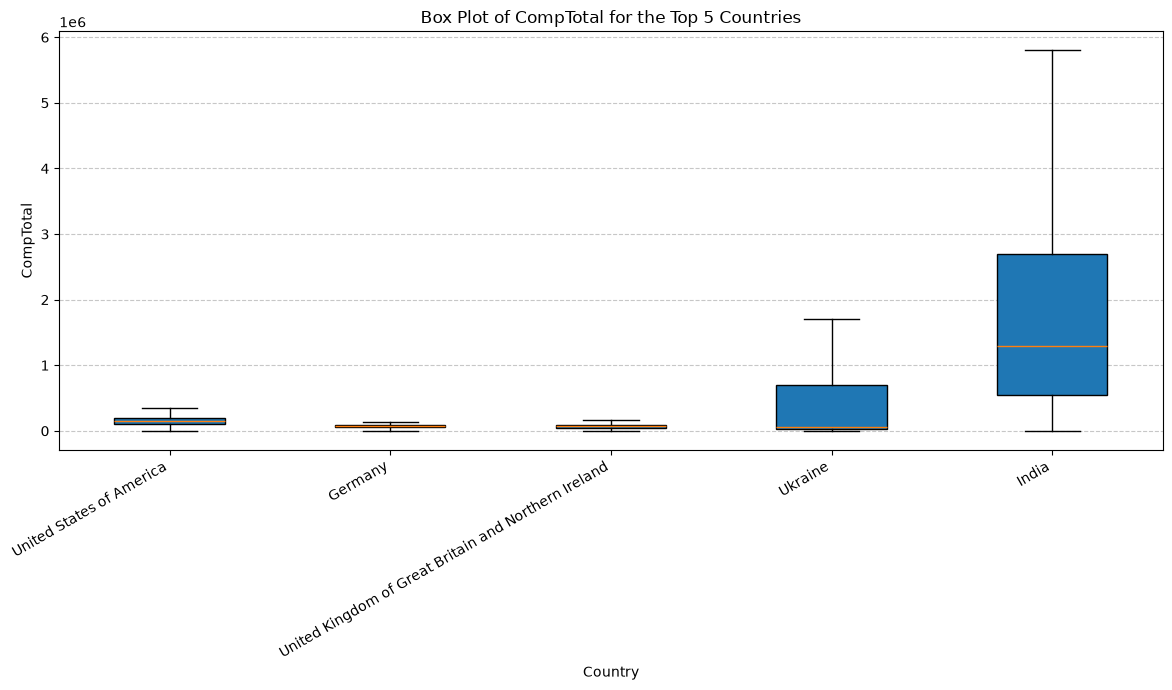

In [12]:
import sqlite3
import matplotlib.pyplot as plt
from collections import Counter

conn = sqlite3.connect("survey-results-public.sqlite")
cursor = conn.cursor()


cursor.execute("""
SELECT Country, CompTotal
FROM main
WHERE Country IS NOT NULL
AND CompTotal IS NOT NULL;
""")

rows = cursor.fetchall()


conn.close()

country_counter = Counter()

for country, _ in rows:
    country_counter[country] += 1


top5_countries = [country for country, count in country_counter.most_common(5)]

comp_by_country = {country: [] for country in top5_countries}

for country, comp in rows:
    if country in comp_by_country:
        try:
            comp = float(comp)
            if comp > 0:
                comp_by_country[country].append(comp)
        except (ValueError, TypeError):
            continue


data = [comp_by_country[country] for country in top5_countries]

plt.figure(figsize=(12, 7))

plt.boxplot(
    data,
    tick_labels=top5_countries,  
    patch_artist=True,
    showfliers=False
)

plt.title("Box Plot of CompTotal for the Top 5 Countries")
plt.xlabel("Country")
plt.ylabel("CompTotal")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


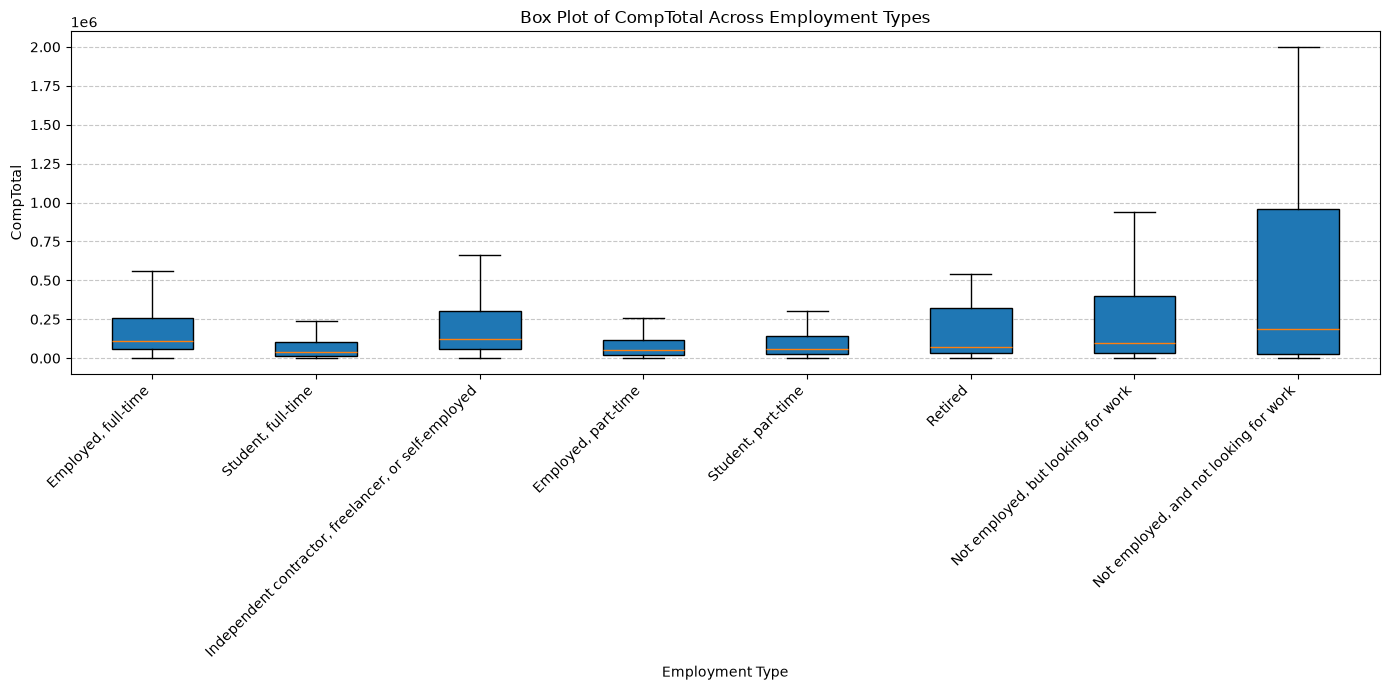

In [13]:
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect("survey-results-public.sqlite")
cursor = conn.cursor()

cursor.execute("""
SELECT Employment, CompTotal
FROM main
WHERE Employment IS NOT NULL
AND CompTotal IS NOT NULL;
""")

rows = cursor.fetchall()

conn.close()

comp_by_employment = {}

for employment, comp in rows:
    try:
        comp = float(comp)

        if comp <= 0:
            continue

        employment_types = [emp.strip() for emp in employment.split(";")]

        for emp in employment_types:
            if emp not in comp_by_employment:
                comp_by_employment[emp] = []
            comp_by_employment[emp].append(comp)

    except (ValueError, TypeError):
        continue

employment_labels = []
data = []

for emp, values in comp_by_employment.items():
    if len(values) > 0:
        employment_labels.append(emp)
        data.append(values)

plt.figure(figsize=(14, 7))

plt.boxplot(
    data,
    tick_labels=employment_labels,   
    patch_artist=True,
    showfliers=False
)

plt.title("Box Plot of CompTotal Across Employment Types")
plt.xlabel("Employment Type")
plt.ylabel("CompTotal")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


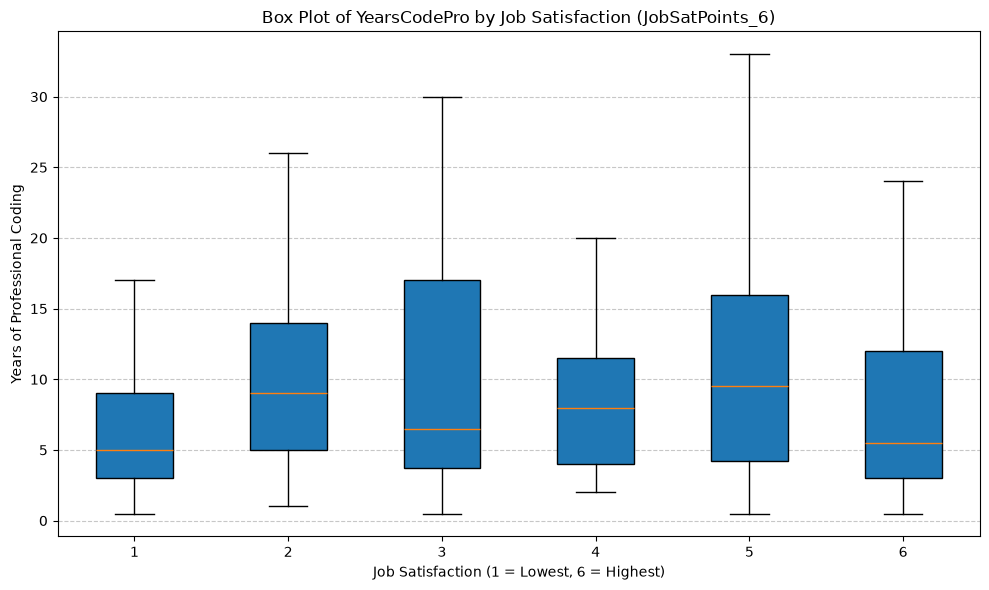

In [14]:
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect("survey-results-public.sqlite")
cursor = conn.cursor()

cursor.execute("""
SELECT YearsCodePro, JobSatPoints_6
FROM main
WHERE YearsCodePro IS NOT NULL
AND JobSatPoints_6 IS NOT NULL;
""")

rows = cursor.fetchall()

conn.close()

years_by_jobsat = {i: [] for i in range(1, 7)}


for years, jobsat in rows:
    try:
        
        if years == "Less than 1 year":
            years = 0.5
        elif years == "More than 50 years":
            years = 51
        else:
            years = float(years)

        jobsat = int(jobsat)

        if jobsat in years_by_jobsat:
            years_by_jobsat[jobsat].append(years)

    except (ValueError, TypeError):
        continue

data = [years_by_jobsat[i] for i in range(1, 7)]

plt.figure(figsize=(10, 6))

plt.boxplot(
    data,
    tick_labels=[str(i) for i in range(1, 7)],   # Matplotlib 3.9+
    patch_artist=True,
    showfliers=False
)

plt.title("Box Plot of YearsCodePro by Job Satisfaction (JobSatPoints_6)")
plt.xlabel("Job Satisfaction (1 = Lowest, 6 = Highest)")
plt.ylabel("Years of Professional Coding")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [15]:
conn.close()
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
